/home/jovyan/.qbraid/environments/alice_g9lq38/pyenv/lib/python3.11/site-packages/equinox/_module.py:1096: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
|██████████| 100.0% ◆ elapsed 05m11s ◆ remaining 0.00ms  


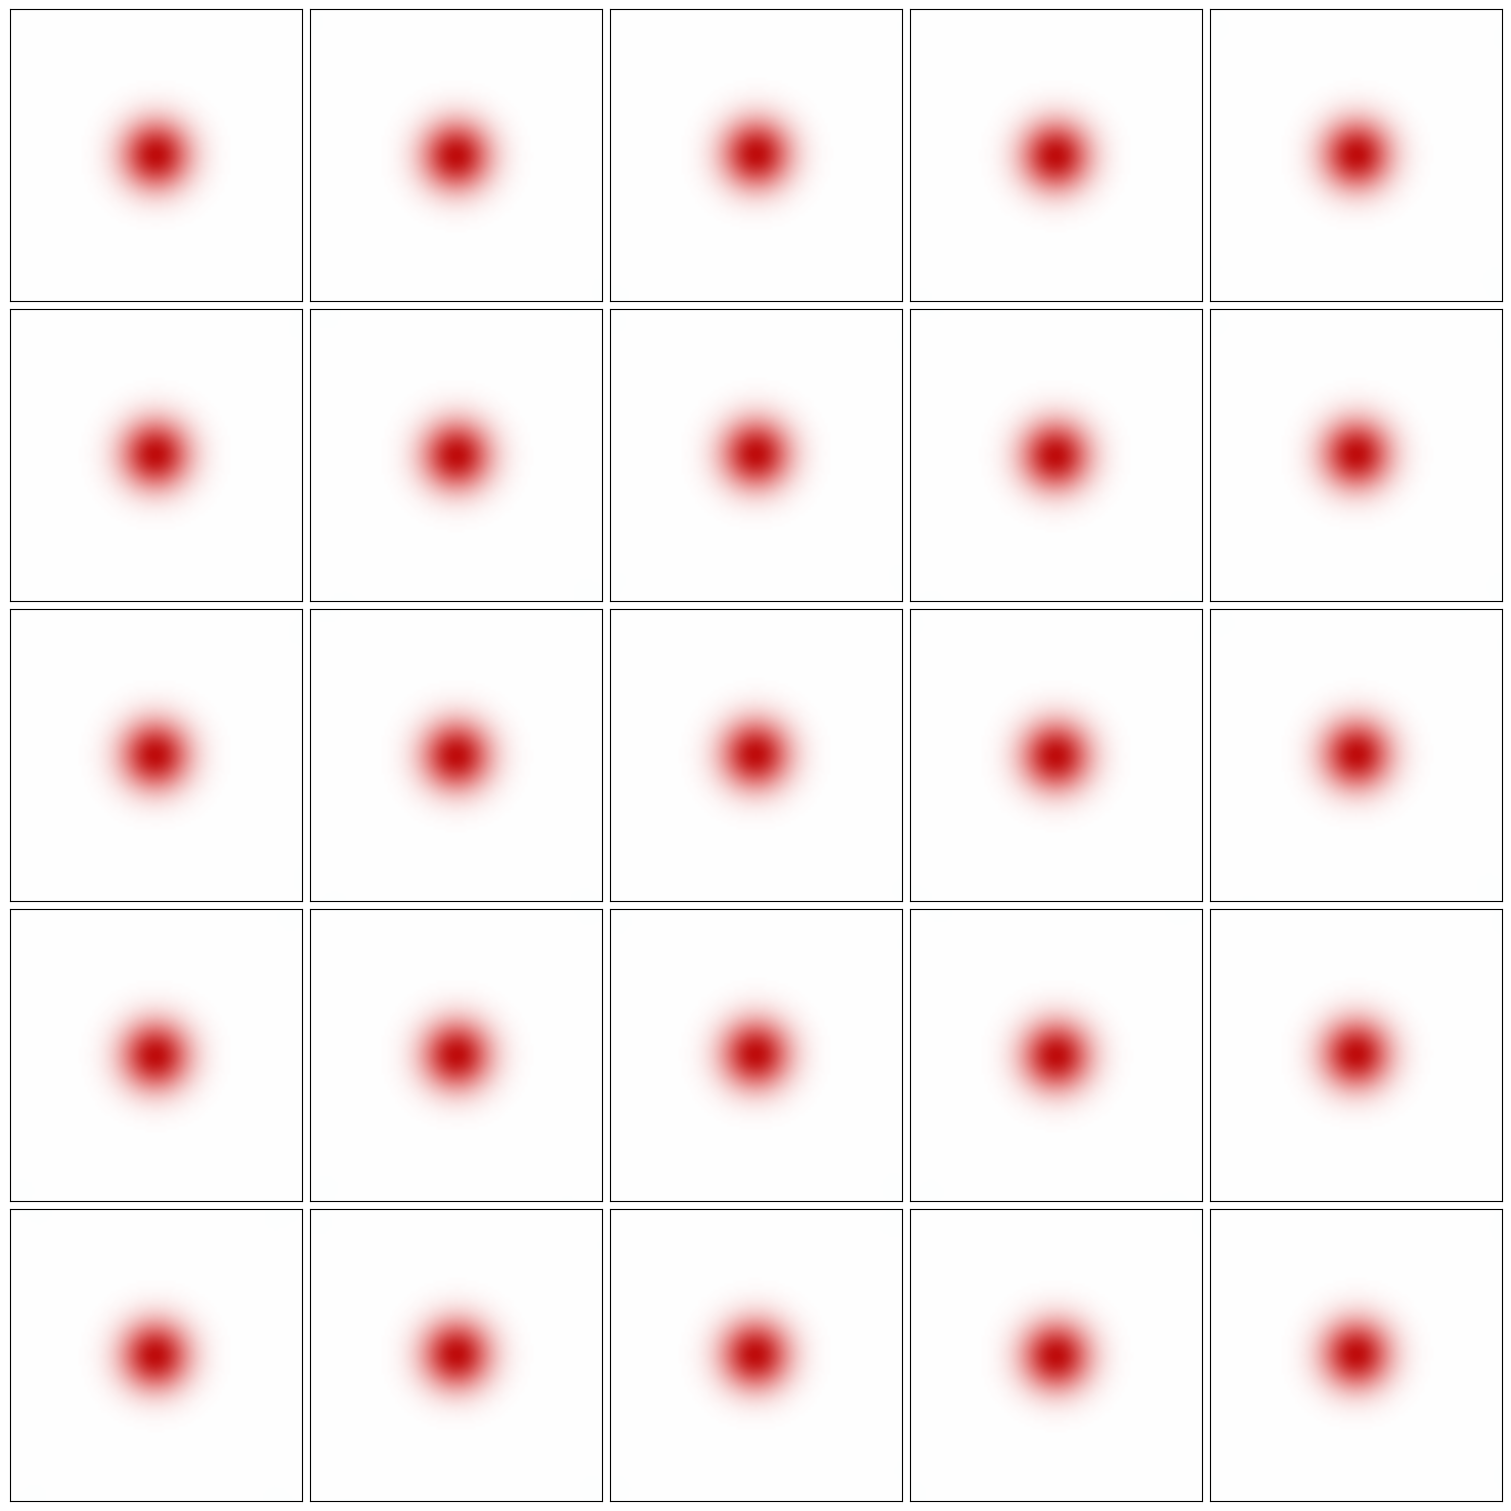

In [26]:
##################################
## ALICE AND BOB CHALLENGE: TASK 2 ##
##################################

## Import necessary packages ##
import dynamiqs as dq
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

## Parameters provided from the Github ##
omega_a = 2 * jnp.pi * 5.26     ##Mode a frequency (GHz)##
omega_b = 2 * jnp.pi * 7.7      ##Mode b frequency (GHz)##
omega_d = 2 * jnp.pi * 7.623    ##Mode b frequency (GHz)##
phi_a = 0.06                    ##Memory phase##
phi_b = 0.29                    ##Buffer phase##
Ej = 42.76                      ##Josephson energy (GHz)##
delta_Ej = 0.47                 ##Energy difference (GHz)##
omega_p = 7.623 * 2 * jnp.pi    ##Pump frequency (rad/s)##
epsilon_p = 0.122               ##Pump amplitude (dimensionless)##
epsilon_d = 2 * jnp.pi * -3.815 ##Drive amplitude (dimensionless)##

##Define dissipation rates##
kappa_b = 2.6 *0.001 ## Buffer decay rate ##
kappa_2 = 2.0   ## Two-photon dissipation rate ##
kappa_1 = 9.3  ## Single-photon loss rate ##

## Define Hilbert space dimensions ##
n_a = 20  # Memory mode truncation
n_b = 5   # Buffer mode truncation


## Create ladder operators ##
a, b = dq.destroy(n_a, n_b)## Annihilation operator for memory mode ##
adag =a.dag()
bdag =b.dag()
phi = .06*(a+adag)+.29*(b+bdag)
## Define time-dependent terms ##
def epsilon_t(t):
    return epsilon_p * jnp.cos(omega_p * t)
    
## Time evolution parameters ##
T = 100  ## Total simulation time ##
time_steps = jnp.linspace(0, T, 200)  ## Time grid ##

## Define Hamiltonian Components ##
H_0 = omega_a * (a.dag() @ a) + omega_b * (b.dag() @ b) ## Bare mode frequencies ##
H_d = dq.modulated(lambda t: 2*epsilon_d *jnp.cos(omega_d*t), (b + b.dag()))  ## Buffer drive ##
## Define ATS Term ##
H_ats1 = dq.modulated( lambda t: (-2 * Ej * jnp.sin(epsilon_t(t))), phi.sinm())  ## ATS term with time dependence ##
H_ats2 = dq.modulated( lambda t: 2 * delta_Ej * jnp.cos(epsilon_t(t)), phi.cosm())

# H_ats_qarray = H_ats * dq.eye(*H_0.dims)  ## Convert scalar to qarray ##
# print(type(H_ats_qarray))

## Define Full Hamiltonian ##
H_lab = H_0 + H_ats1+H_ats2 + H_d



## Define collapse operators ##
c_ops = [
    dq.asqarray(jnp.sqrt(kappa_b) * b),  ## Buffer mode decay ##
    #dq.asqarray(jnp.sqrt(kappa_2) * (a @ a)),  ## Two-photon dissipation ##
    dq.asqarray(jnp.sqrt(kappa_1) * a),  ## Single-photon loss ##
]

## Define initial state ##
psi0 = dq.fock((n_a, n_b), (0, 0))

## Solve the Lindblad Master Equation ##
result = dq.mesolve(H_lab, c_ops, psi0, time_steps)

rho_a =dq.ptrace(result.states,0)

dq.plot.wigner_gif(result.states, fps=25, xmax=4.0, ymax=2.0)
